# Assignment 2: Data Wrangling II
## Academic Performance Dataset using Python

**Name:** ___________ | **Class:** T.E. | **Roll No:** ___________

## Problem Statement
To create an academic performance dataset of students and perform data wrangling operations including handling missing values and inconsistencies, detecting and treating outliers, and applying appropriate data transformations.

## Theory
**Missing Values & Inconsistencies:** Datasets may contain incomplete data. Handled by filling (mean/median/mode) or dropping rows/columns.

**Outlier Detection (IQR Method):**
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 * IQR
- Upper Bound = Q3 + 1.5 * IQR

**Outlier Treatment (Capping/Winsorization):** Values below lower bound replaced with lower bound; above upper bound replaced with upper bound.

**Data Transformations:** Log transformation (reduces skewness), Min-Max Normalization (scales to [0,1]).

In [13]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [14]:
# Step 2: Set Random Seed for Reproducibility
np.random.seed(42)
print("Random seed set to 42")

Random seed set to 42


In [15]:
# Step 3: Generate Synthetic Academic Dataset (200 students)
n = 200
data = {
    'student_id': range(1, n + 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'age': np.random.randint(18, 26, n),
    'study_hours': np.round(np.random.normal(5, 2, n), 1),
    'attendance': np.round(np.random.uniform(50, 100, n), 1),
    'previous_gpa': np.round(np.random.uniform(2.0, 4.0, n), 2),
    'final_exam_score': np.random.randint(30, 100, n),
    'parent_education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n),
    'internet_access': np.random.choice(['Yes', 'No'], n)
}

df = pd.DataFrame(data)
# Introduce some outliers for demonstration
df.loc[0, 'study_hours'] = 20.0   # extreme outlier
df.loc[1, 'study_hours'] = 0.1    # extreme outlier
df.loc[2, 'final_exam_score'] = 5 # extreme outlier
df.loc[3, 'final_exam_score'] = 120 # beyond max

print("Dataset created!")
print(f"Shape: {df.shape}")
df.head(10)

Dataset created!
Shape: (200, 9)


,student_id,gender,age,study_hours,attendance,previous_gpa,final_exam_score,parent_education,internet_access
0,1,Male,24,20.0,71.2,3.17,85,Master,Yes
1,2,Female,25,0.1,95.3,3.49,91,PhD,No
2,3,Male,24,5.6,55.6,2.86,5,Master,No
3,4,Male,18,3.6,74.6,2.26,120,Master,Yes
4,5,Male,21,8.7,50.6,2.57,58,PhD,Yes
5,6,Female,22,5.9,73.4,2.73,78,High School,No
6,7,Male,25,2.6,52.8,3.29,74,PhD,Yes
7,8,Male,21,6.3,55.9,3.14,59,High School,No
8,9,Male,23,3.1,55.9,2.71,45,Bachelor,No
9,10,Female,22,6.6,82.5,3.97,69,High School,No


In [16]:
# Step 4: Check for Missing Values
print("Missing values per column:")
print(df.isnull().sum())
print("No missing values found (synthetically generated).")

Missing values per column:
student_id          0
gender              0
age                 0
study_hours         0
attendance          0
previous_gpa        0
final_exam_score    0
parent_education    0
internet_access     0
dtype: int64
No missing values found (synthetically generated).


In [17]:
# Step 5: Check Data Types
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
student_id            int64
gender               object
age                   int32
study_hours         float64
attendance          float64
previous_gpa        float64
final_exam_score      int32
parent_education     object
internet_access      object
dtype: object


In [18]:
# Step 6: Convert Categorical Variables
df['gender'] = df['gender'].astype('category')
df['parent_education'] = df['parent_education'].astype('category')
df['internet_access'] = df['internet_access'].astype('category')

print("Categorical columns converted.")
print(df.dtypes)

Categorical columns converted.
student_id             int64
gender              category
age                    int32
study_hours          float64
attendance           float64
previous_gpa         float64
final_exam_score       int32
parent_education    category
internet_access     category
dtype: object


In [19]:
# Step 7: Select Numeric Columns for Analysis
numeric_cols = ['age', 'study_hours', 'attendance', 'previous_gpa', 'final_exam_score']
df_numeric = df[numeric_cols].copy()
print("Numeric columns:", numeric_cols)
df_numeric.describe()

Numeric columns: ['age', 'study_hours', 'attendance', 'previous_gpa', 'final_exam_score']


,age,study_hours,attendance,previous_gpa,final_exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,21.455000,5.190500,74.803500,2.998900,63.180000
std,2.399325,2.230704,14.935787,0.566705,20.423841
min,18.000000,-1.500000,50.600000,2.010000,5.000000
25%,19.750000,3.675000,61.350000,2.497500,46.000000
50%,21.000000,5.200000,74.600000,3.005000,63.000000
75%,24.000000,6.400000,87.500000,3.490000,80.500000
max,25.000000,20.000000,100.000000,3.990000,120.000000


In [20]:
# Step 8: Compute Quartiles (Q1, Q3)
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)

print("Q1 (25th percentile):")
print(Q1)
print("Q3 (75th percentile):")
print(Q3)

Q1 (25th percentile):
age                 19.7500
study_hours          3.6750
attendance          61.3500
previous_gpa         2.4975
final_exam_score    46.0000
Name: 0.25, dtype: float64
Q3 (75th percentile):
age                 24.00
study_hours          6.40
attendance          87.50
previous_gpa         3.49
final_exam_score    80.50
Name: 0.75, dtype: float64


In [21]:
# Step 9: Calculate Interquartile Range (IQR)
IQR = Q3 - Q1
print("IQR for each numeric column:")
print(IQR)

IQR for each numeric column:
age                  4.2500
study_hours          2.7250
attendance          26.1500
previous_gpa         0.9925
final_exam_score    34.5000
dtype: float64


In [22]:
# Step 10: Detect Outliers Using IQR Method
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bounds:")
print(lower_bound)
print("Upper bounds:")
print(upper_bound)

outliers = {}
for col in numeric_cols:
    mask = (df_numeric[col] < lower_bound[col]) | (df_numeric[col] > upper_bound[col])
    outliers[col] = mask.sum()
    print(f"{col}: {outliers[col]} outliers detected")

Lower bounds:
age                 13.37500
study_hours         -0.41250
attendance          22.12500
previous_gpa         1.00875
final_exam_score    -5.75000
dtype: float64
Upper bounds:
age                  30.37500
study_hours          10.48750
attendance          126.72500
previous_gpa          4.97875
final_exam_score    132.25000
dtype: float64
age: 0 outliers detected
study_hours: 3 outliers detected
attendance: 0 outliers detected
previous_gpa: 0 outliers detected
final_exam_score: 0 outliers detected


In [23]:
# Step 11: Treat Outliers Using Capping (Winsorization)
df_capped = df_numeric.copy()
for col in numeric_cols:
    df_capped[col] = np.where(
        df_capped[col] < lower_bound[col], lower_bound[col],
        np.where(df_capped[col] > upper_bound[col], upper_bound[col], df_capped[col])
    )

print("Outliers treated using capping.")
print("Before capping - describe:")
print(df_numeric.describe())
print("After capping - describe:")
print(df_capped.describe())

Outliers treated using capping.
Before capping - describe:
              age  study_hours  attendance  previous_gpa  final_exam_score
count  200.000000   200.000000  200.000000    200.000000        200.000000
mean    21.455000     5.190500   74.803500      2.998900         63.180000
std      2.399325     2.230704   14.935787      0.566705         20.423841
min     18.000000    -1.500000   50.600000      2.010000          5.000000
25%     19.750000     3.675000   61.350000      2.497500         46.000000
50%     21.000000     5.200000   74.600000      3.005000         63.000000
75%     24.000000     6.400000   87.500000      3.490000         80.500000
max     25.000000    20.000000  100.000000      3.990000        120.000000
After capping - describe:
              age  study_hours  attendance  previous_gpa  final_exam_score
count  200.000000   200.000000  200.000000    200.000000        200.000000
mean    21.455000     5.137312   74.803500      2.998900         63.180000
std      2.3993

In [24]:
# Step 12: Verify Outlier Removal
# Check if any values remain outside bounds
remaining = 0
for col in numeric_cols:
    outside = ((df_capped[col] < lower_bound[col]) | (df_capped[col] > upper_bound[col])).sum()
    remaining += outside
    print(f"{col}: {outside} values outside bounds")

print(f"Total remaining outliers: {remaining}")
print("Outlier treatment successful!" if remaining == 0 else "Some outliers remain.")

age: 0 values outside bounds
study_hours: 0 values outside bounds
attendance: 0 values outside bounds
previous_gpa: 0 values outside bounds
final_exam_score: 0 values outside bounds
Total remaining outliers: 0
Outlier treatment successful!


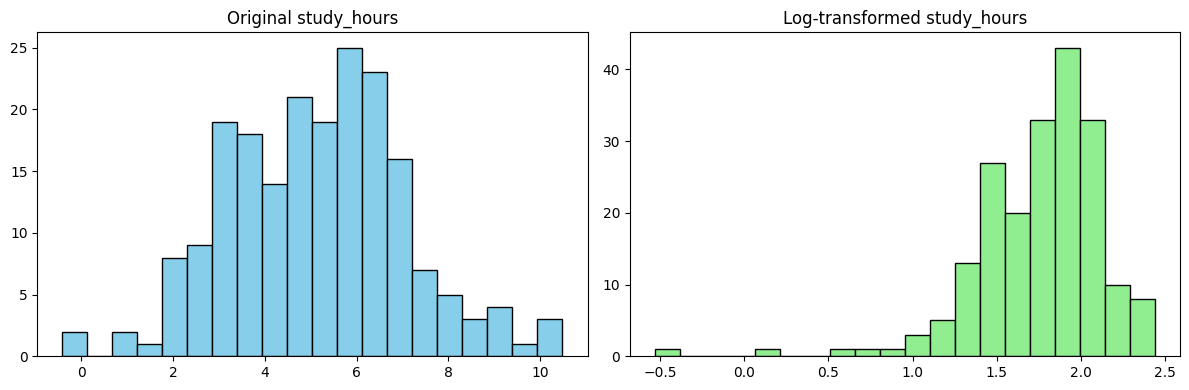

In [28]:
# Step 13: Apply Log Transformation
# Apply log1p to study_hours (adds 1 to handle zeros)
# df_capped['study_hours_log'] = np.log1p(df_capped['study_hours'])

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_capped['study_hours'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Original study_hours')
axes[1].hist(df_capped['study_hours_log'], bins=20, color='lightgreen', edgecolor='black')
axes[1].set_title('Log-transformed study_hours')
plt.tight_layout()
plt.show()

In [26]:
# Step 14: Apply Normalization (Min-Max Scaling)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_capped['final_exam_score_normalized'] = scaler.fit_transform(
    df_capped[['final_exam_score']]
)

print("Min-Max Scaling applied to final_exam_score.")
print(f"Original range: [{df_capped['final_exam_score'].min():.2f}, {df_capped['final_exam_score'].max():.2f}]")
print(f"Normalized range: [{df_capped['final_exam_score_normalized'].min():.4f}, {df_capped['final_exam_score_normalized'].max():.4f}]")

Min-Max Scaling applied to final_exam_score.
Original range: [5.00, 120.00]
Normalized range: [0.0000, 1.0000]


In [27]:
# Step 15: Display Final Processed Dataset
print("FINAL PROCESSED DATASET")
print(f"Shape: {df_capped.shape}")
print("Summary statistics:")
df_capped.describe()

FINAL PROCESSED DATASET
Shape: (200, 7)
Summary statistics:


,age,study_hours,attendance,previous_gpa,final_exam_score,study_hours_log,final_exam_score_normalized
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,21.455000,5.137312,74.803500,2.998900,63.180000,1.753324,0.505913
std,2.399325,1.950003,14.935787,0.566705,20.423841,0.382242,0.177599
min,18.000000,-0.412500,50.600000,2.010000,5.000000,-0.531879,0.000000
25%,19.750000,3.675000,61.350000,2.497500,46.000000,1.542186,0.356522
50%,21.000000,5.200000,74.600000,3.005000,63.000000,1.824549,0.504348
75%,24.000000,6.400000,87.500000,3.490000,80.500000,2.001480,0.656522
max,25.000000,10.487500,100.000000,3.990000,120.000000,2.441259,1.000000


## Dataset Description
- **Type:** Synthetic academic dataset
- **Records:** 200 students
- **Features:** student_id, gender, age, study_hours, attendance, previous_gpa, final_exam_score, parent_education, internet_access

## Conclusion
Data wrangling performed: missing values checked (none found), outliers detected via IQR and treated using capping, log transformation applied to study_hours, and min-max normalization applied to final_exam_score. Dataset is now clean and ready for analysis.